In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict

In [12]:
df = pd.read_csv('../dataset/cmi_internet_imputed.csv')


In [13]:
# Basic inspection
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,sii
0,5.0,0.0,51,46.000000,50.8,26.000000,69,5,87,114,...,1,24.434900,8.895360,38.9177,19.541300,2.129038,60,3,448,2.0
1,9.0,0.0,66,48.000000,46.0,22.000000,75,5,70,122,...,1,21.035200,14.974000,39.4497,15.410700,2.010000,64,0,434,0.0
2,10.0,1.0,71,56.500000,75.6,25.982899,65,5,94,117,...,2,28.910638,27.225876,56.9964,31.077528,2.170000,54,2,453,0.0
3,9.0,0.0,71,56.000000,81.6,26.000000,60,6,97,117,...,2,30.404100,16.779000,58.9338,26.479800,2.451000,45,0,577,1.0
4,18.0,1.0,65,62.213593,77.0,26.000000,68,5,80,116,...,2,28.855800,23.969174,56.9964,33.821493,1.040000,58,1,433,0.0


In [15]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical columns:", len(num_cols))
print(num_cols)

Number of numerical columns: 32
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time', 'sii']


## Naive Approaches


### Box Plots

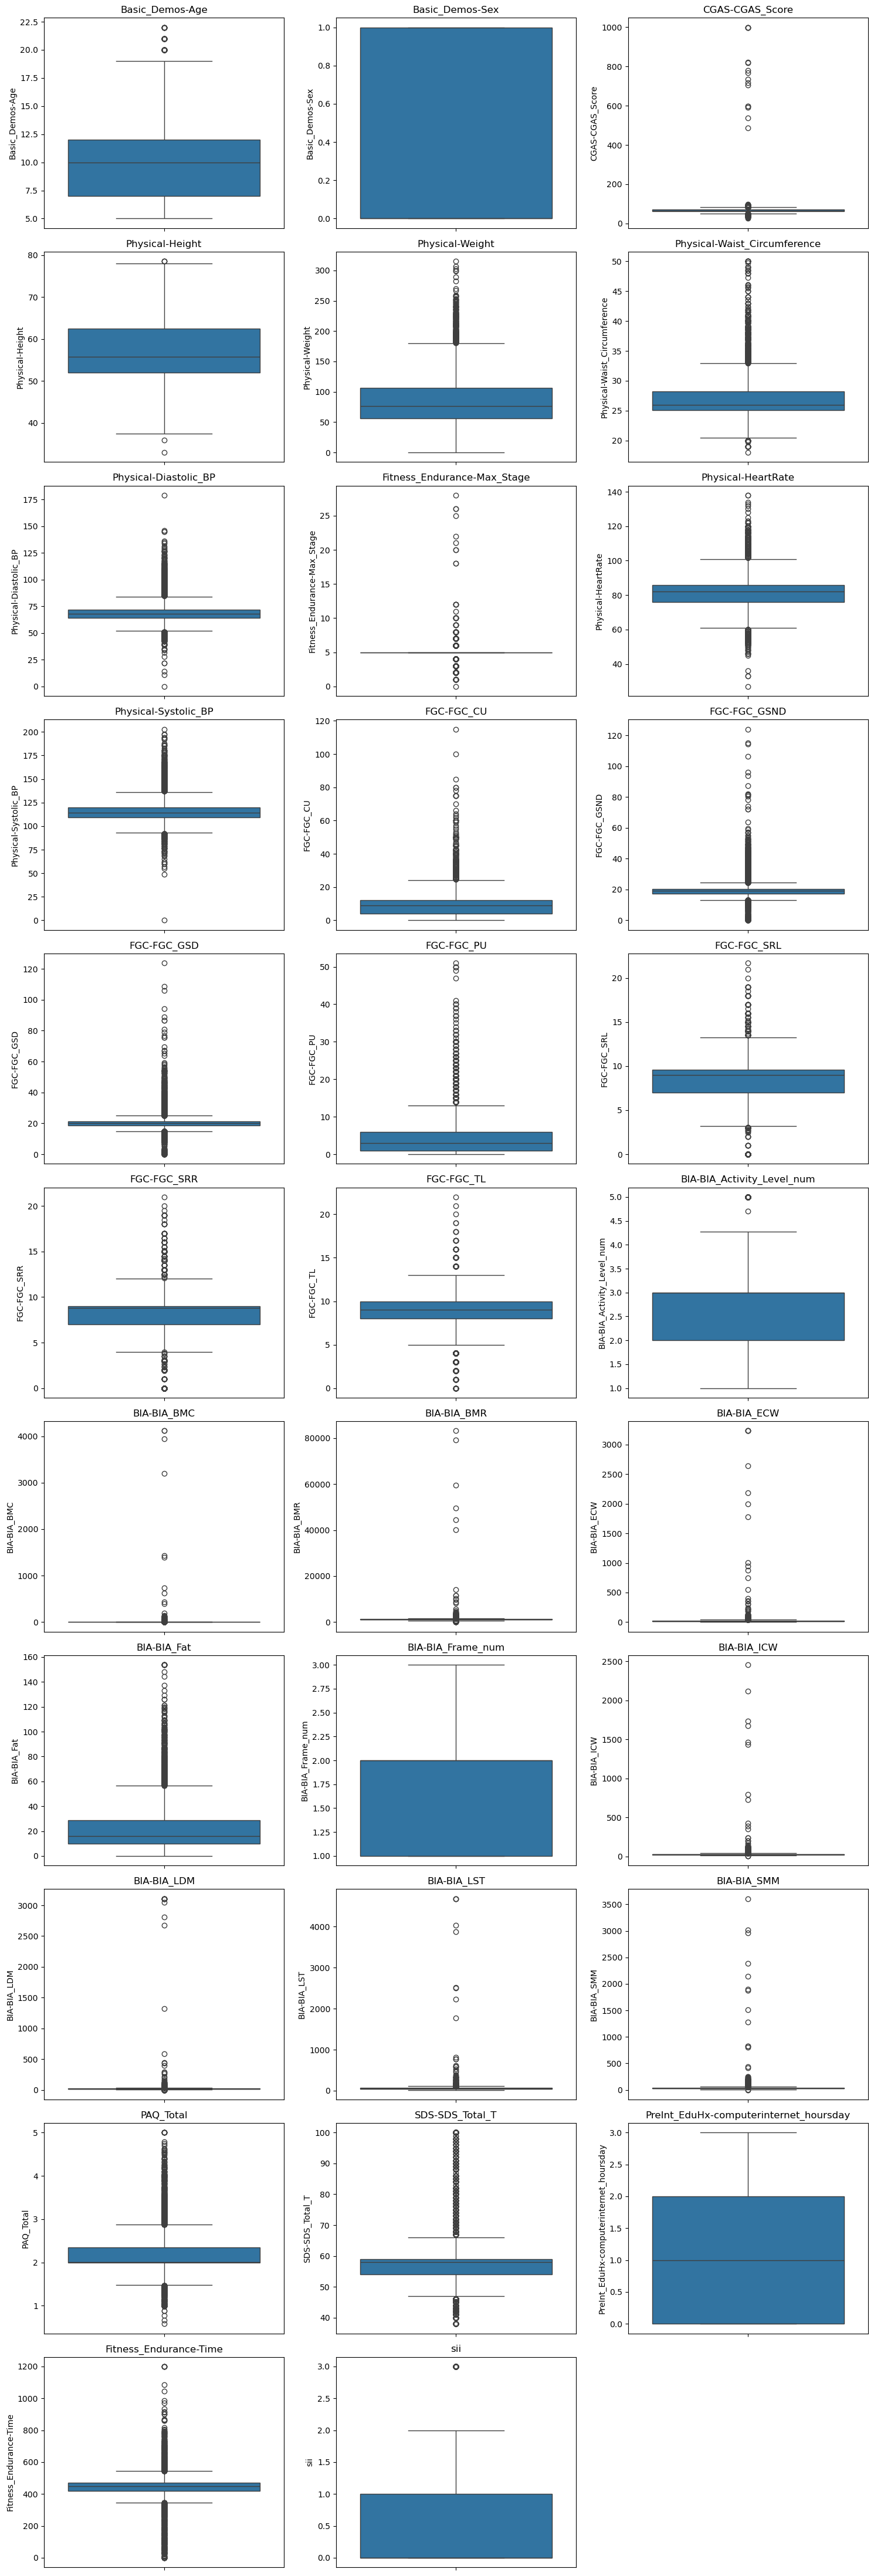

In [16]:
# Boxplots for all numerical variables
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [17]:
def iqr_outlier_mask(data, columns, k=1.5):
    """
    Returns a boolean DataFrame:
    True means that the value is an outlier according to the IQR rule.
    """
    outlier_mask = pd.DataFrame(False, index=data.index, columns=columns)

    bounds = {}

    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - k * IQR
        upper_bound = Q3 + k * IQR

        outlier_mask[col] = (data[col] < lower_bound) | (data[col] > upper_bound)

        bounds[col] = {
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        }

    bounds = pd.DataFrame(bounds).T

    return outlier_mask, bounds

In [18]:
iqr_mask, iqr_bounds = iqr_outlier_mask(df, num_cols, k=1.5)

iqr_bounds

,Q1,Q3,IQR,lower_bound,upper_bound
Basic_Demos-Age,7.000000,12.000000,5.000000,-0.500000,19.500000
Basic_Demos-Sex,0.000000,1.000000,1.000000,-1.500000,2.500000
CGAS-CGAS_Score,62.000000,70.000000,8.000000,50.000000,82.000000
Physical-Height,51.990000,62.500000,10.510000,36.225000,78.265000
Physical-Weight,56.600000,106.100000,49.500000,-17.650000,180.350000
Physical-Waist_Circumference,25.100000,28.250000,3.150000,20.375000,32.975000
Physical-Diastolic_BP,64.000000,72.000000,8.000000,52.000000,84.000000
Fitness_Endurance-Max_Stage,5.000000,5.000000,0.000000,5.000000,5.000000
Physical-HeartRate,76.000000,86.000000,10.000000,61.000000,101.000000
Physical-Systolic_BP,109.000000,120.000000,11.000000,92.500000,136.500000


In [19]:
outliers_per_variable = iqr_mask.sum().sort_values(ascending=False)

outliers_per_variable

Fitness_Endurance-Max_Stage               2620
FGC-FGC_GSD                               1894
PAQ_Total                                 1737
SDS-SDS_Total_T                           1713
FGC-FGC_GSND                              1524
Fitness_Endurance-Time                     951
FGC-FGC_SRR                                764
Physical-Systolic_BP                       729
Physical-Diastolic_BP                      724
BIA-BIA_ICW                                710
FGC-FGC_TL                                 619
CGAS-CGAS_Score                            606
Physical-HeartRate                         596
BIA-BIA_BMC                                577
FGC-FGC_PU                                 566
BIA-BIA_LST                                484
BIA-BIA_SMM                                473
Physical-Waist_Circumference               470
FGC-FGC_CU                                 451
BIA-BIA_BMR                                443
BIA-BIA_LDM                                412
BIA-BIA_Fat  

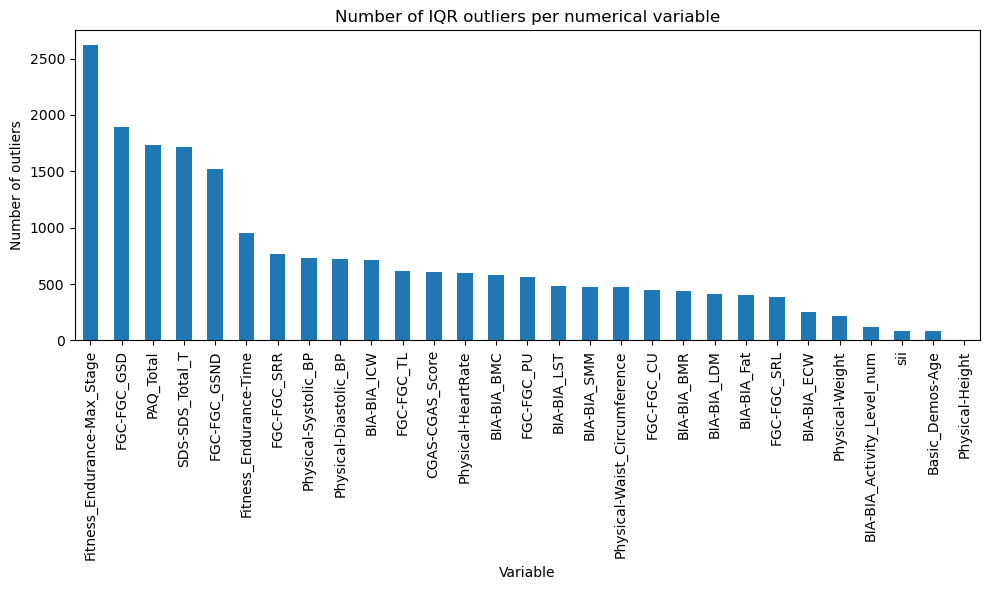

In [20]:
plt.figure(figsize=(10, 6))
outliers_per_variable[outliers_per_variable > 0].plot(kind="bar")
plt.title("Number of IQR outliers per numerical variable")
plt.ylabel("Number of outliers")
plt.xlabel("Variable")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

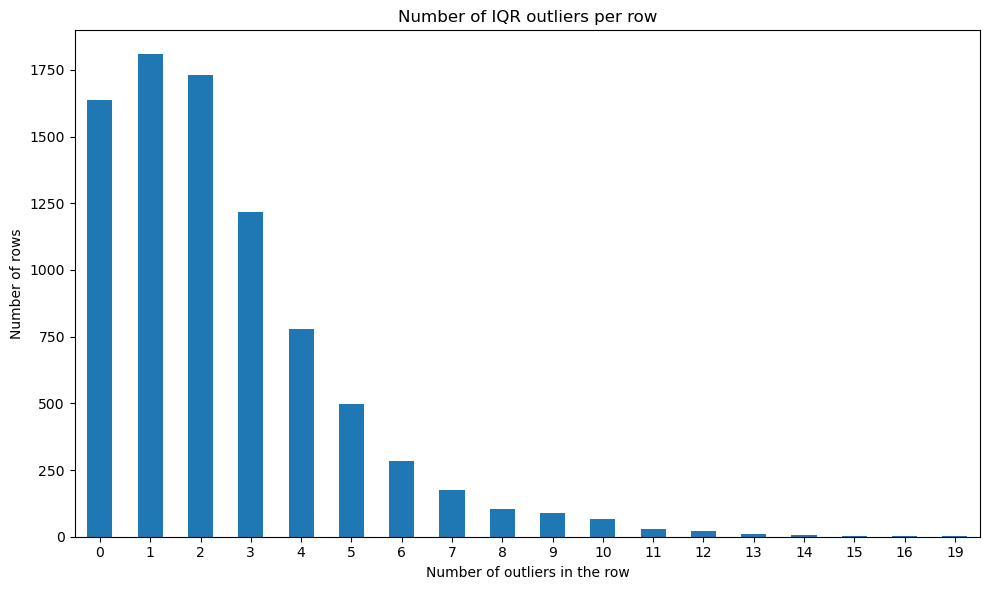

In [23]:
#count the number of outliers per row
outliers_per_row = iqr_mask.sum(axis=1)
outliers_per_row.value_counts().sort_index()
plt.figure(figsize=(10, 6))
outliers_per_row.value_counts().sort_index().plot(kind="bar")
plt.title("Number of IQR outliers per row")
plt.ylabel("Number of rows")
plt.xlabel("Number of outliers in the row")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### HBOS

In [26]:
 !pip install pyod

In [28]:
from pyod.models.hbos import HBOS
from sklearn.preprocessing import StandardScaler

In [29]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

X = df[num_cols].copy()

print("Numerical variables used for HBOS:")
print(num_cols)
print("Shape:", X.shape)

Numerical variables used for HBOS:
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time', 'sii']
Shape: (8460, 32)


In [30]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=num_cols,
    index=df.index
)

X_scaled.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,sii
0,-1.466005,-0.820524,-0.498013,-1.557409,-0.864848,-0.281158,0.008835,0.102005,0.474900,-0.122879,...,-1.375678,-0.147202,-0.145140,-0.237769,-0.189612,-0.180694,0.200873,1.985093,0.088778,2.128877
1,-0.346958,-0.820524,-0.031901,-1.278714,-0.987759,-1.456477,0.575087,0.102005,-1.099996,0.476246,...,-1.375678,-0.213382,-0.090231,-0.233342,-0.240660,-0.402784,0.617237,-0.969843,-0.072985,-0.607211
2,-0.067196,1.218734,0.123470,-0.094260,-0.229808,-0.286183,-0.368666,0.102005,1.123386,0.101793,...,0.443649,-0.060075,0.020440,-0.087325,-0.047041,-0.104271,-0.423672,1.000114,0.146551,-0.607211
3,-0.346958,-0.820524,0.123470,-0.163933,-0.076169,-0.281158,-0.840542,1.091641,1.401309,0.101793,...,0.443649,-0.031003,-0.073927,-0.071203,-0.103863,0.419992,-1.360491,-0.969843,1.579309,0.760833
4,2.170899,1.218734,-0.062975,0.701916,-0.193958,-0.281158,-0.085540,0.102005,-0.173587,0.026902,...,0.443649,-0.061143,-0.008977,-0.087325,-0.013130,-2.212518,-0.007309,0.015136,-0.084539,-0.607211


In [31]:
hbos = HBOS(
    n_bins=10,
    contamination=0.05
)

hbos.fit(X_scaled)

HBOS(alpha=0.1, contamination=0.05, n_bins=10, tol=0.5)

In [32]:
df_hbos = df.copy()

df_hbos["hbos_score"] = hbos.decision_scores_
df_hbos["hbos_label"] = hbos.labels_

df_hbos[["hbos_score", "hbos_label"]].head()

,hbos_score,hbos_label
0,34.445689,0
1,36.310658,0
2,32.723602,0
3,35.665348,0
4,28.509391,0


In [33]:
n_outliers = df_hbos["hbos_label"].sum()
perc_outliers = n_outliers / len(df_hbos) * 100

print("Number of HBOS outliers:", n_outliers)
print("Percentage of HBOS outliers:", round(perc_outliers, 2), "%")

Number of HBOS outliers: 423
Percentage of HBOS outliers: 5.0 %


In [34]:
df_hbos_sorted = df_hbos.sort_values("hbos_score", ascending=False)

df_hbos_sorted.head(20)

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,sii,hbos_score,hbos_label
87,17.0,0.0,64,77.00,224.600000,37.000000,72,5,71,144,...,20.040074,56.996400,27.415100,4.170000,60,2,448,0.0,63.585651,1
306,16.0,0.0,63,67.50,298.800000,49.000000,72,5,93,157,...,46.759400,171.380000,82.303300,1.380000,91,3,420,3.0,60.655264,1
2036,12.0,0.0,80,65.00,175.000000,31.820631,71,5,86,136,...,31.509400,121.092000,60.569100,3.890000,84,2,513,3.0,59.902791,1
356,12.0,0.0,69,65.00,152.000000,34.000000,120,5,94,139,...,27.104100,92.842200,43.512900,4.040000,40,0,490,0.0,58.921763,1
3935,15.0,0.0,48,66.00,182.200000,39.000000,83,4,102,146,...,31.168500,115.263000,53.638000,1.120000,56,3,420,1.0,58.589434,1
1947,15.0,0.0,65,69.50,192.600000,37.000000,84,5,89,131,...,33.697400,117.743000,51.745000,1.670000,100,3,459,2.0,58.468829,1
489,17.0,0.0,70,69.50,240.600000,33.756483,100,5,102,166,...,43.079900,155.277000,97.923100,2.380000,45,0,448,0.0,57.809948,1
636,15.0,0.0,70,65.25,149.800000,26.000000,53,5,91,115,...,29.572000,115.621000,64.286900,1.880000,64,3,507,1.0,57.262032,1
932,17.0,0.0,60,68.00,125.000000,28.435485,52,6,46,111,...,27.390900,101.967000,54.543400,4.540000,56,3,562,1.0,57.091197,1
1662,16.0,0.0,55,71.00,232.000000,34.938623,79,4,102,105,...,41.741400,150.859000,81.746000,1.250000,69,2,448,0.0,57.074253,1


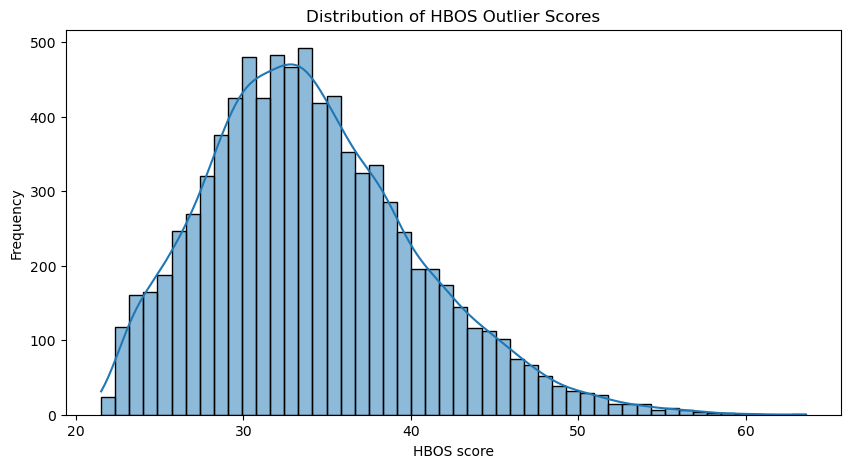

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(df_hbos["hbos_score"], bins=50, kde=True)
plt.title("Distribution of HBOS Outlier Scores")
plt.xlabel("HBOS score")
plt.ylabel("Frequency")
plt.show()

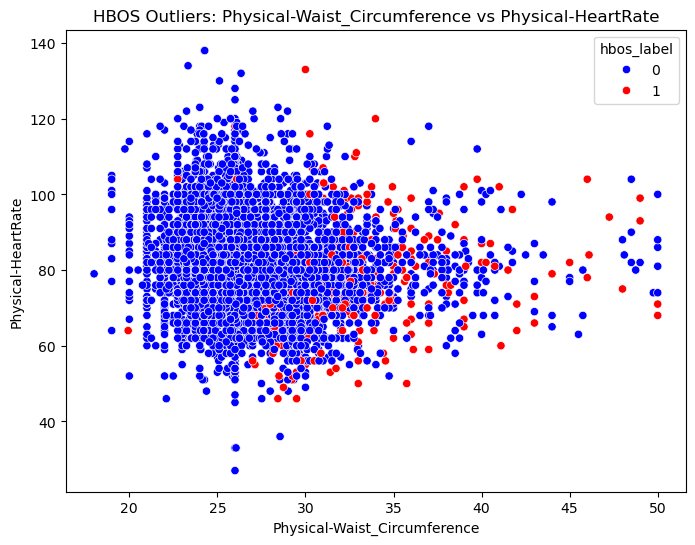

In [41]:
# visualize normal vs outlier observations in a scatter plot using two numerical variables
x_col = num_cols[5]
y_col = num_cols[8]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_hbos,
    x=x_col,
    y=y_col,
    hue="hbos_label",
    palette={0: "blue", 1: "red"}
)

plt.title(f"HBOS Outliers: {x_col} vs {y_col}")
plt.show()

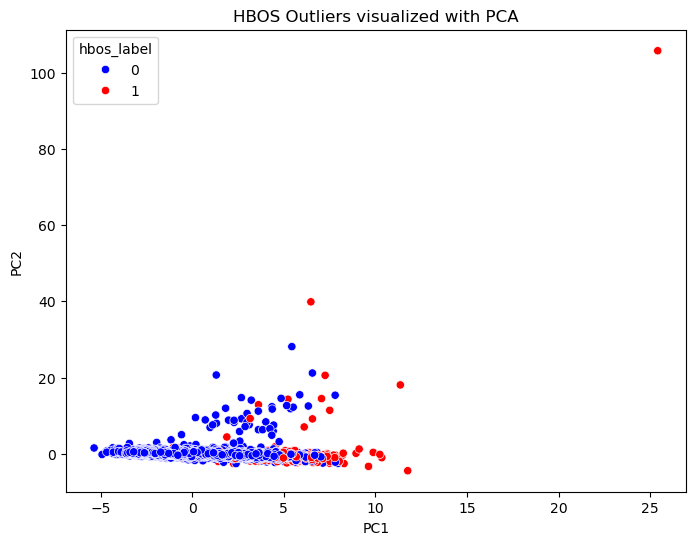

In [43]:
#try to visualize the outliers in a 2D space using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_hbos["PC1"] = X_pca[:, 0]
df_hbos["PC2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_hbos,
    x="PC1",
    y="PC2",
    hue="hbos_label",
    palette={0: "blue", 1: "red"}
)

plt.title("HBOS Outliers visualized with PCA")
plt.show()

In [46]:
#comparison between IQR outliers and HBOS outliers
comparison = pd.crosstab(
    df_outlier_summary["is_iqr_outlier"],
    df_hbos["hbos_label"],
    rownames=["IQR outlier"],
    colnames=["HBOS label"]
)

comparison


HBOS label,0,1
IQR outlier,,
False,1639,0
True,6398,423


In [47]:
comparison = pd.crosstab(
    df_outlier_summary["is_iqr_outlier"].map({False: "IQR normal", True: "IQR outlier"}),
    df_hbos["hbos_label"].map({0: "HBOS normal", 1: "HBOS outlier"})
)

comparison

hbos_label,HBOS normal,HBOS outlier
is_iqr_outlier,,
IQR normal,1639,0
IQR outlier,6398,423
